## 1. First, we need to load the data




In [1]:
import torch
from torch import nn
from pathlib import Path
import os

In [2]:
torch.cuda.is_available()

True

We can load the data from kaggle.

But first, we need to download kaggle and its api structure before we start extracting the data from the dataset.

**NOTE** : After you download kaggle using `pip install kaggle`, you must create a token in your kaggle account which will download a `.json` file and you need to move it to `~/.kaggle/kaggle.json`

**STEP 1**: Download kaggle.

In [3]:
!pip install kaggle

**STEP 2**: Download token from your kaggle account: `Click your profile found in top right -> Settings -> Create New Token`

This will download a `kaggle.json` file which you need to move to `~/.kaggle`.

Run the following code.

In [4]:

!cp ~/Downloads/kaggle.json ~/.kaggle/kaggle.json

'cp' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
# Make sure it exists
!ls ~/.kaggle/

'ls' is not recognized as an internal or external command,
operable program or batch file.


**STEP 3**: Now, we need to download `kagglehub`. Note that the dataset's size is 29.2 GB so make sure you have enough space to download this dataset. You can always delete the dataset if you want after you finish using it.

In [6]:
!pip install kagglehub

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sergeynesteruk/packed-fruits-and-vegetables-recognition-benchmark")

print("Path to dataset files:", path)


KeyboardInterrupt: 

**Step 4:** Now that you downlaoded the dataset, it's time to move it to the current directory of this notebook.

In [ ]:

import shutil
import os

source_path = os.path.expanduser("~/.cache/kagglehub/datasets/sergeynesteruk/packed-fruits-and-vegetables-recognition-benchmark/versions/5")

# we need to create the new directory first
current_directory = os.getcwd()
new_directory = os.path.join(current_directory, "data")
os.makedirs(new_directory, exist_ok=True)

# Now we can move the data from where it is right now to the new data folder that we crfeated in the current directory where this notebook is located
shutil.move(source_path, new_directory)


'c:\\Users\\Adullah\\OneDrive\\Desktop\\suman421159-CSCI4622-001-ML-Fall2024-Project\\models\\data\\5'

The following code is just for renaming the directory name.

In [3]:
data_dir = "data/fruits_vegetables"

In [ ]:

new_directory_name = os.path.join(os.getcwd(), data_dir)
old_directory_name = os.path.join(os.getcwd(), "data/5")
os.rename(old_directory_name, new_directory_name)
# old_directory_name

## 2. Visualize the data we have before we turn it into numerical representation

Let's use `matplotlib` to visualize our data so that we can see what we have first.

### 2.1 Create the necessary paths first.

In [4]:
import random
from PIL import Image

# Use Path this time
data_dir = Path("data/fruits_vegetables")

#
img_path_list = list(data_dir.glob("*/*/*/*.jpg"))
len(img_path_list)



111726

data\fruits_vegetables\train\train\pepper_sweet_green\028978.jpg
pepper_sweet_green
Image width: 1440
Image height: 1080


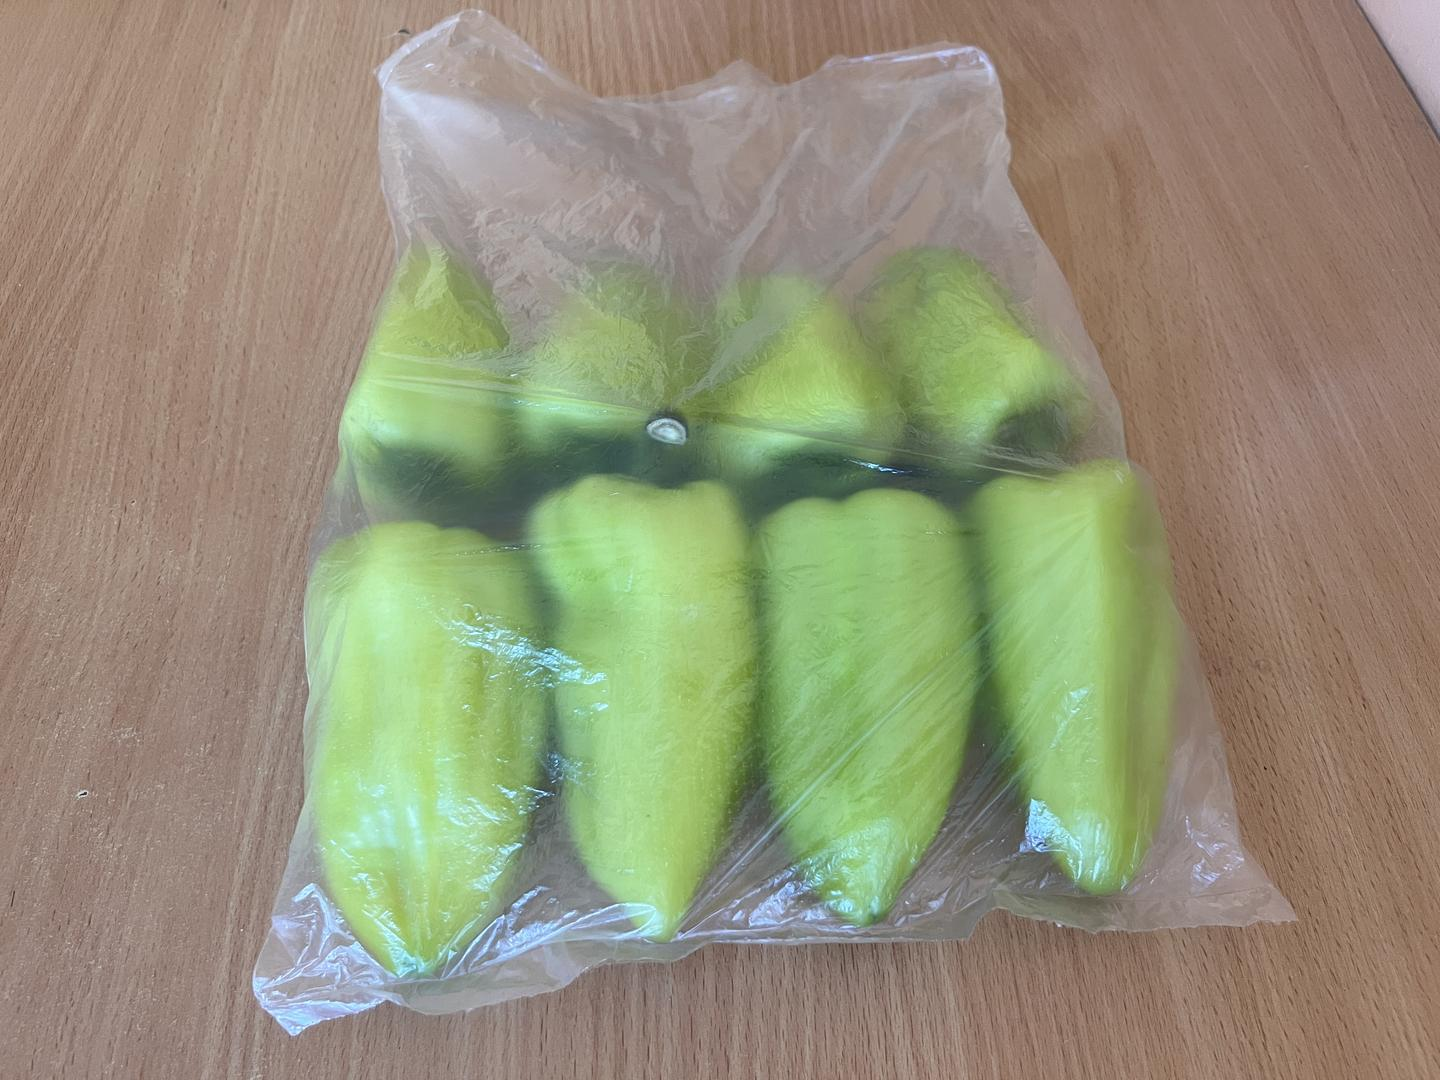

In [5]:
# Continuing on, we need to display one of the images randomly
random.seed(42)
random_img = random.choice(img_path_list)
print(random_img)
# we need to convert this random image into numpy data because we won't be able to visualize unless the data is in numpy form (we will plot this later on but not right now)
random_image_class = random_img.parent.stem
print(random_image_class)

# display image
img = Image.open(random_img)
print(f"Image width: {img.width}")
print(f"Image height: {img.height}")
img

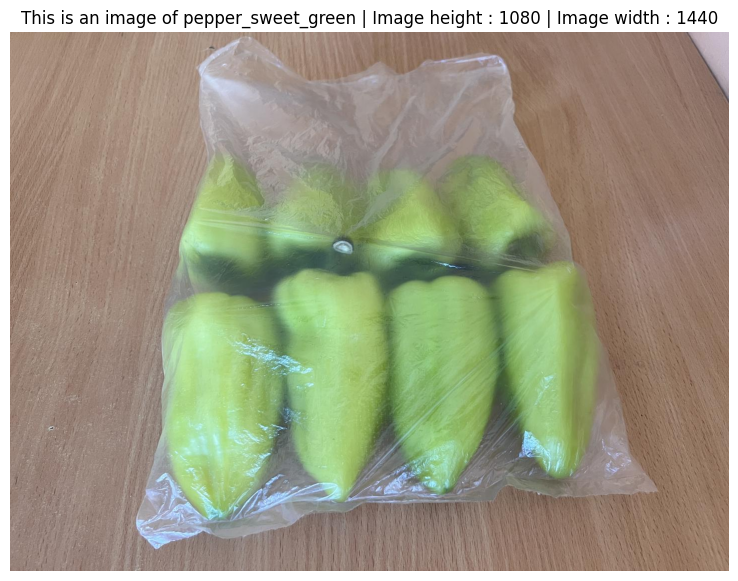

In [6]:
# Now we can plot it here
import numpy as np
import matplotlib.pyplot as plt

# turn it into numpy array
img_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_array)
plt.title(f"This is an image of {random_image_class} | Image height : {img.height} | Image width : {img.width}")
plt.axis(False);

In [7]:
# You can see the img as numpy array here
img_array, img_array.shape

(array([[[161, 134, 113],
         [171, 144, 123],
         [162, 135, 114],
         ...,
         [205, 193, 207],
         [205, 193, 207],
         [205, 193, 207]],
 
        [[164, 137, 116],
         [169, 142, 121],
         [158, 131, 110],
         ...,
         [205, 193, 207],
         [205, 193, 207],
         [205, 193, 207]],
 
        [[166, 139, 118],
         [168, 141, 120],
         [155, 128, 107],
         ...,
         [204, 192, 206],
         [203, 191, 205],
         [203, 191, 205]],
 
        ...,
 
        [[143, 120, 112],
         [135, 112, 104],
         [141, 118, 110],
         ...,
         [161, 130, 110],
         [162, 131, 111],
         [165, 134, 114]],
 
        [[144, 121, 113],
         [136, 113, 105],
         [143, 120, 112],
         ...,
         [164, 133, 113],
         [161, 130, 110],
         [162, 131, 111]],
 
        [[147, 124, 116],
         [139, 116, 108],
         [145, 122, 114],
         ...,
         [166, 135, 115],
  

## 3. Data Preparation (Turning the data into PyTorch Tensors)

Now that we have loaded our images into the current directory that we are working on, we can now turn that those images into numbers. Namely, we must turn them into PyTorch Tensors so that our future PyTorch models can train on those data.

In [8]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
data_transform = transforms.Compose([
    transforms.Resize(size=(256,256)),
    transforms.ToTensor()
])
data_transform

Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

In [10]:
def plot_transformed_image(file_paths, n = 3, seed = None):
    # if seed is given, then apply it
    if seed is not None:
        random.seed(seed)
    if n > 3 or n <= 0:
        n = 3
    random_paths = random.choices(file_paths,  k=n) # randomly sample n images from the list that is given
    for random_path in random_paths:
        with Image.open(random_path) as f:
            # now we want to plot the figure before we transform it
            img_class = random_path.parent.stem
            plt.figure(figsize=(15,7))
            plt.subplot(1,2,1)
            plt.imshow(f)
            plt.title(f"Image class: {img_class} | Image height : {f.height} | Image width : {f.width}")
            plt.axis(False)

            # Now we turn our data into pytorch tensors and plot the data 
            img_tensor = data_transform(f).permute(1,2,0) # the reason thjat we permute is that numpy and matplotlib expects the color channels at the beginning whereas the color channels in tensors are located at the end
            plt.subplot(1,2,2)
            plt.imshow(img_tensor)
            plt.title(f"Image class: {img_class} | Image height : {img_tensor.shape[0]} | Image width : {img_tensor.shape[1]}")
            plt.axis(False)



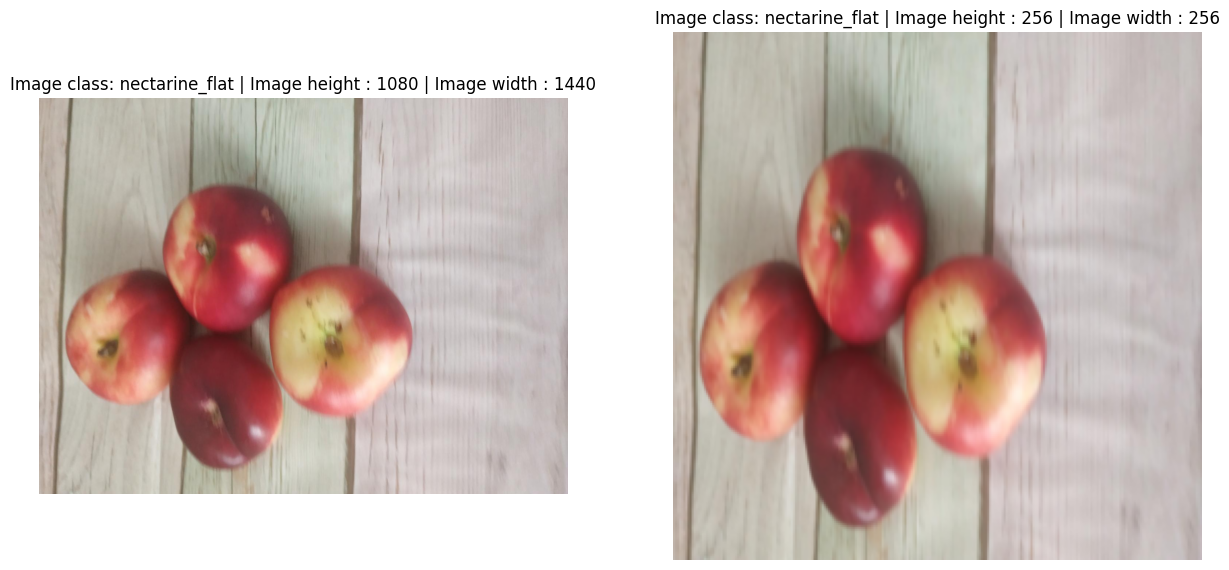

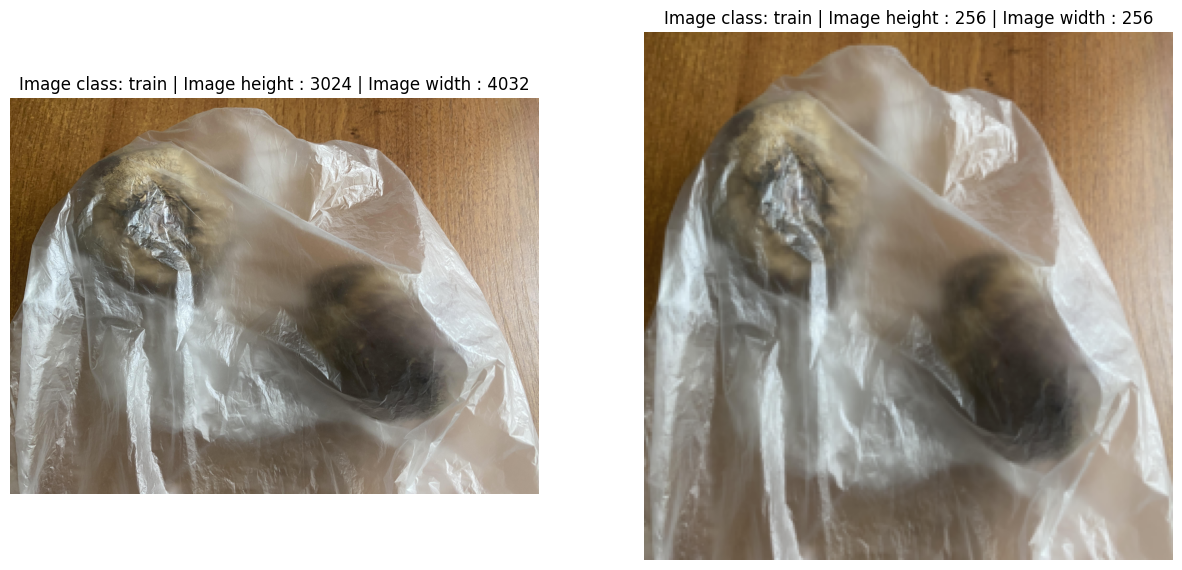

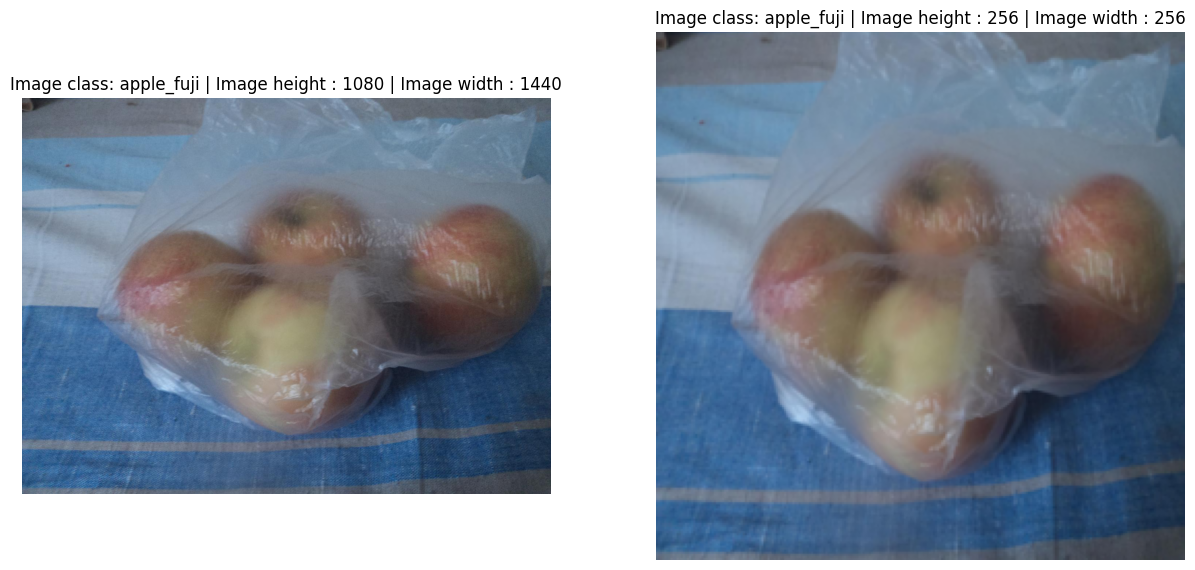

In [11]:
plot_transformed_image(file_paths=img_path_list, n=3, seed=42)

In [12]:
random.choices(img_path_list)[0]

WindowsPath('data/fruits_vegetables/test/test/pomelo_pomelo/052118.jpg')

In [13]:
with Image.open(random.choices(img_path_list)[0]) as f: # sample of how this function works from Image
    temp = data_transform(f)
temp

tensor([[[0.6706, 0.6392, 0.6314,  ..., 0.5843, 0.5608, 0.5373],
         [0.7451, 0.6667, 0.6902,  ..., 0.6039, 0.6196, 0.5608],
         [0.7686, 0.7412, 0.7294,  ..., 0.6392, 0.6549, 0.5961],
         ...,
         [0.6275, 0.6196, 0.5843,  ..., 0.5098, 0.5137, 0.4510],
         [0.6902, 0.6392, 0.6000,  ..., 0.4667, 0.4824, 0.4196],
         [0.7333, 0.6706, 0.6196,  ..., 0.4157, 0.4275, 0.3804]],

        [[0.5176, 0.4863, 0.4706,  ..., 0.4196, 0.3922, 0.3686],
         [0.5922, 0.5098, 0.5373,  ..., 0.4471, 0.4588, 0.3961],
         [0.6118, 0.5882, 0.5765,  ..., 0.4863, 0.5020, 0.4431],
         ...,
         [0.5529, 0.5451, 0.5059,  ..., 0.4078, 0.4078, 0.3373],
         [0.6000, 0.5608, 0.5333,  ..., 0.3490, 0.3882, 0.3373],
         [0.6392, 0.5961, 0.5569,  ..., 0.2941, 0.3333, 0.3059]],

        [[0.2471, 0.2275, 0.2314,  ..., 0.1922, 0.1765, 0.1608],
         [0.3294, 0.2549, 0.2824,  ..., 0.2196, 0.2353, 0.1882],
         [0.3647, 0.3294, 0.3098,  ..., 0.2549, 0.2784, 0.

### 3.1 Use `ImageFolder`

We can use `ImageFolder` to transform every image that we have into tensors seperated by the type of the image (ie. whether the image is training data or testing data).

In [14]:
# First, we need the root of the train directory
train_dir = Path("data/fruits_vegetables/train/train")

# Second, fetch the test directory
test_dir = Path("data/fruits_vegetables/test/test")


train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data


(Dataset ImageFolder
     Number of datapoints: 81084
     Root location: data\fruits_vegetables\train\train
     StandardTransform
 Transform: Compose(
                Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 21951
     Root location: data\fruits_vegetables\test\test
     StandardTransform
 Transform: Compose(
                Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [15]:
len(train_data.classes), len(test_data.classes) # This is a problem because the training data has 65 classes whereas the testing data has 64 classes and we will do something later on in this notebook

(64, 64)

In [16]:
train_data.classes[:10], test_data.classes[:10]

(['apple_fuji',
  'apple_golden',
  'apple_granny',
  'apple_ligol',
  'apple_red_delicious',
  'apple_spartan',
  'apricot_armenian',
  'apricot_jerdel',
  'avocado_hass',
  'avocado_zutano'],
 ['apple_fuji',
  'apple_golden',
  'apple_granny',
  'apple_ligol',
  'apple_red_delicious',
  'apple_spartan',
  'apricot_armenian',
  'apricot_jerdel',
  'avocado_hass',
  'avocado_zutano'])

In [17]:
class_names = train_data.classes
class_names

['apple_fuji',
 'apple_golden',
 'apple_granny',
 'apple_ligol',
 'apple_red_delicious',
 'apple_spartan',
 'apricot_armenian',
 'apricot_jerdel',
 'avocado_hass',
 'avocado_zutano',
 'banana_mini',
 'banana_yellow',
 'beet_round',
 'cabbage_broccoli',
 'cabbage_cauliflower',
 'cabbage_peking',
 'cabbage_white',
 'carrot_carrot',
 'corn_corn',
 'cucumber_long',
 'cucumber_medium',
 'daikon_daikon',
 'garlic_garlic',
 'grape_black',
 'grape_green',
 'grape_pink',
 'kiwi_kiwi',
 'lemon_orange',
 'lemon_yellow',
 'lime_lime',
 'mango_mango',
 'melon_torpeda',
 'nectarine_flat',
 'nectarine_round',
 'onion_purple',
 'onion_white',
 'orange_orange',
 'pear_conference',
 'pear_williams_rouge',
 'pepper_chili',
 'pepper_sweet_elonged',
 'pepper_sweet_green',
 'pepper_sweet_red',
 'pepper_sweet_yellow',
 'plum_pink',
 'plum_purple',
 'pomegranate_pomegranate',
 'pomelo_pomelo',
 'potato_pink',
 'potato_yellow',
 'pumpkin_elonged',
 'raddish_elonged',
 'raddish_round',
 'salad_green',
 'tangeri

In [18]:
class_dict = train_data.class_to_idx,
class_dict

({'apple_fuji': 0,
  'apple_golden': 1,
  'apple_granny': 2,
  'apple_ligol': 3,
  'apple_red_delicious': 4,
  'apple_spartan': 5,
  'apricot_armenian': 6,
  'apricot_jerdel': 7,
  'avocado_hass': 8,
  'avocado_zutano': 9,
  'banana_mini': 10,
  'banana_yellow': 11,
  'beet_round': 12,
  'cabbage_broccoli': 13,
  'cabbage_cauliflower': 14,
  'cabbage_peking': 15,
  'cabbage_white': 16,
  'carrot_carrot': 17,
  'corn_corn': 18,
  'cucumber_long': 19,
  'cucumber_medium': 20,
  'daikon_daikon': 21,
  'garlic_garlic': 22,
  'grape_black': 23,
  'grape_green': 24,
  'grape_pink': 25,
  'kiwi_kiwi': 26,
  'lemon_orange': 27,
  'lemon_yellow': 28,
  'lime_lime': 29,
  'mango_mango': 30,
  'melon_torpeda': 31,
  'nectarine_flat': 32,
  'nectarine_round': 33,
  'onion_purple': 34,
  'onion_white': 35,
  'orange_orange': 36,
  'pear_conference': 37,
  'pear_williams_rouge': 38,
  'pepper_chili': 39,
  'pepper_sweet_elonged': 40,
  'pepper_sweet_green': 41,
  'pepper_sweet_red': 42,
  'pepper_sw

In [19]:
img, label = train_data[0][0], train_data[0][1]
label

0

In [20]:
class_names[label]

'apple_fuji'

In [21]:
print(f"Image : {img}")
print(f"Image data type: {img.dtype}")
print(f"Image shape: {img.shape}")
print(f"Image class : {label}")
print(f"Image class data type: {type(label)}")

Image : tensor([[[0.1412, 0.1412, 0.1451,  ..., 0.1922, 0.2039, 0.2235],
         [0.1373, 0.1333, 0.1255,  ..., 0.1843, 0.2078, 0.2314],
         [0.0902, 0.0784, 0.0588,  ..., 0.0980, 0.1804, 0.2157],
         ...,
         [0.0706, 0.0706, 0.0745,  ..., 0.0235, 0.0235, 0.0314],
         [0.0824, 0.0824, 0.0902,  ..., 0.0275, 0.0275, 0.0353],
         [0.0667, 0.0667, 0.0706,  ..., 0.0353, 0.0471, 0.0471]],

        [[0.0980, 0.0980, 0.1020,  ..., 0.1529, 0.1608, 0.1686],
         [0.1059, 0.1020, 0.0941,  ..., 0.1529, 0.1725, 0.1843],
         [0.0745, 0.0667, 0.0431,  ..., 0.0784, 0.1529, 0.1804],
         ...,
         [0.0627, 0.0627, 0.0667,  ..., 0.0157, 0.0157, 0.0235],
         [0.0824, 0.0784, 0.0863,  ..., 0.0235, 0.0275, 0.0353],
         [0.0667, 0.0667, 0.0706,  ..., 0.0353, 0.0471, 0.0471]],

        [[0.0667, 0.0667, 0.0667,  ..., 0.1176, 0.1255, 0.1333],
         [0.0824, 0.0784, 0.0706,  ..., 0.1294, 0.1373, 0.1451],
         [0.0627, 0.0510, 0.0314,  ..., 0.0667, 0.

(-0.5, 255.5, 255.5, -0.5)

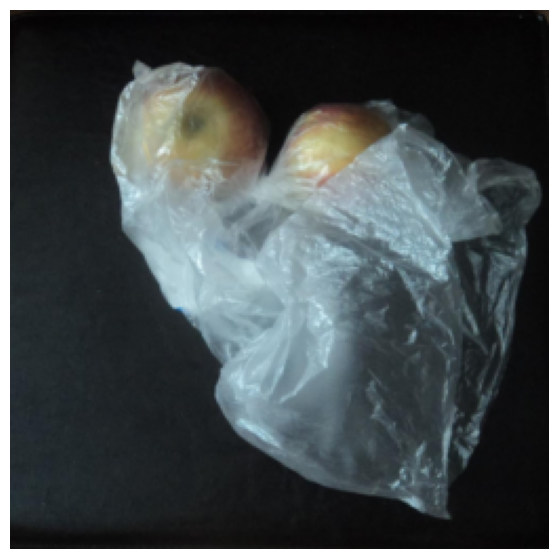

In [22]:
# Let's plot the image

plt.figure(figsize=(15,7))
plt.imshow(img.permute(1,2,0))
plt.axis(False)

### 3.2 Now we need to transform our data into batches using `DataLoader`

Now, we need to transform our data into batches of images using `DataLoader` so that we can train our model easily with no problem

In [23]:
# Set hyperparamter variables
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# Create the batches using dataloaders
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True,
                              pin_memory=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             pin_memory=True)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x173e8e6b210>,
 <torch.utils.data.dataloader.DataLoader at 0x173f1085ad0>)

In [24]:
len(test_dataloader), len(train_dataloader)

(686, 2534)

In [25]:
train_data.classes[60:], test_data.classes[60:] # i turns out that grapefruit_grapefruit is the extra class that the train data have and the test data does not


(['tomato_yellow', 'watermelon_elonged', 'zucchini_green', 'zucchini_white'],
 ['tomato_yellow', 'watermelon_elonged', 'zucchini_green', 'zucchini_white'])

In [26]:
train_data.class_to_idx["grapefruit_grapefruit"], test_data.class_to_idx["grapefruit_grapefruit"] # it does not exist as you can see here

KeyError: 'grapefruit_grapefruit'

Before, we train our data, we must remove the extra training class that the testing data does not have, and this class is the grapefruit.

We can move this by removing it from the testing folder and out of the folder as follows.



In [27]:
import shutil
source_dir = os.path.join(os.getcwd(), "data/fruits_vegetables/train/train/grapefruit_grapefruit")
dest_dir = os.getcwd()

if(os.path.exists(os.path.join(os.getcwd(), "grapefruit_grapefruit"))):
    print(f"Folder already exists...skipping moving operation.")
else:
    shutil.move(source_dir, dest_dir)

Folder already exists...skipping moving operation.


Now, we need to turn our data again to tensors and then use the dataloader to turn them into batches.

In [28]:
train_dir, test_dir

(WindowsPath('data/fruits_vegetables/train/train'),
 WindowsPath('data/fruits_vegetables/test/test'))

In [29]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 81084
     Root location: data\fruits_vegetables\train\train
     StandardTransform
 Transform: Compose(
                Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 21951
     Root location: data\fruits_vegetables\test\test
     StandardTransform
 Transform: Compose(
                Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [30]:
len(train_data.classes), len(test_data.classes), train_data.classes == test_data.classes

(64, 64, True)

In [31]:
class_names = train_data.classes
class_dict = train_data.class_to_idx

Now, turn the data into batches using dataloaders

In [32]:
os.cpu_count()

16

In [33]:
BATCH_SIZE = 5
NUM_WORKERS = os.cpu_count()
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS)

In [34]:
!nvidia-smi

Thu Dec 12 09:05:43 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 59%   48C    P8             14W /  170W |     907MiB /  12288MiB |     24%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4 Create a model

Now is the time that we create a model. In this notebook, we will be using VGG32 to train our model since they are quite good at training large number of images such as the ones that we are dealing with in this problem set, and since it is quite faster than the other models out there.

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [36]:
class VGG32V1(nn.Module):
    def __init__(self, input_shape : int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_5 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units,
                      out_features = hidden_units),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)
        )
    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = self.conv_layer_5(x)
        print(x)
        x = self.classifier(x)
        return x
        # return self.classifier(self.conv_layer_5(self.conv_layer_4(self.conv_layer_3(self.conv_layer_2(self.conv_layer_1(x))))))


In [37]:
import gc
torch.cuda.empty_cache()
gc.collect()

13763

In [39]:
img_batch, label_batch = next(iter(train_dataloader))
img_batch.shape, label_batch.shape

(torch.Size([5, 3, 256, 256]), torch.Size([5]))

## 4.2 Create train loop and test loop functions

Now that we made sure that our model does not produce any errors or warning when passing a sample data to the function, let's now create train and test functions that we can use to finally train and test our data.



In [41]:
import math
math.floor(len(train_dataloader) * 0.2),math.floor(len(test_dataloader) * 0.2), (len(train_data)), len((test_data))

(3243, 878, 81084, 21951)

In [111]:
def train_loop(model : torch.nn.Module,
               optimizer : torch.optim.Optimizer,
               loss_fn : torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               device = device):
    
    # Put the model in train mode
    model.train()

    # Initialize variables
    train_loss, train_acc  = 0,0

    scaler = torch.amp.GradScaler(device = "cuda")

    for batch, (X,y) in enumerate(dataloader):
        X,y = X.to(device), y.to(device)

        with torch.amp.autocast(device_type = "cuda"):
                #
                y_pred = model(X)
                # Calculate train_loss
                loss = loss_fn(y_pred, y)

        
        train_loss += loss.item()

        # zero the optimizer
        optimizer.zero_grad()

        # loss backward 
        scaler.scale(loss).backward()

        # step the optimizer to adjust new paramters of the model_0
        scaler.step(optimizer)

        scaler.update()

        # Calculate acc
        y_pred_class = torch.argmax(y_pred, dim=1) # need to turn this from logits to actual predictions
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

        
        del X, y, y_pred  # Delete unnecessary variables
        torch.cuda.empty_cache()  # Clear CUDA cache to free up memory
        gc.collect()
        
        
    
    torch.cuda.empty_cache()
    gc.collect()


    train_loss /= len(dataloader) # average dataloader
    train_acc /= len(dataloader) # average acc of all batches

    return train_loss, train_acc





In [114]:
def test_loop(model : torch.nn.Module,
              loss_fn : torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              device = device):
    model.eval()

    test_loss, test_acc  = 0,0

    
    
    # this is important whenever you are making predictions as part of your test loop
    with torch.no_grad():
        for batch, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device) # Again this is just to move the data to the device where the model is located

            with torch.amp.autocast(device_type = "cuda"):
                
                y_pred = model(X)
                # Calculate train_loss
                loss = loss_fn(y_pred, y)

        
            test_loss += loss.item()

            # Calculate per accuracy
            y_pred_class = torch.argmax(y_pred, dim=1)
            test_acc += (y_pred_class == y).sum().item()/len(y_pred_class)

           
            # torch.cuda.empty_cache() # clear cache
            # gc.collect() # deals with unreferenced objects
            del X, y, y_pred  # Delete unnecessary variables
            torch.cuda.empty_cache()  # Clear CUDA cache to free up memory
            gc.collect()

            

        
        torch.cuda.empty_cache()
        gc.collect()
        test_acc /= len(dataloader)
        test_loss /= len(dataloader)

        return test_loss, test_acc
        


### 4.3 Now we need to create a function called `train()` that combines the two 



In [113]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          optimizer : torch.optim.Optimizer,
          loss_fn : torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          epochs : int = 5,
          device = device):
    results = {"train_loss" : [],
               "train_acc" : [],
               "test_loss" : [],
               "test_acc" : []} # this is just for tracking the data across different epochs
    for epoch in tqdm(range(epochs)):

        print(f"Epoch : {epoch}, entering train_loop")
        
        
        train_loss, train_acc = train_loop(model=model,optimizer=optimizer, loss_fn=loss_fn, dataloader=train_dataloader, device=device)

        print(f"Epoch : {epoch}, entering test_loop")

        test_loss, test_acc = test_loop(model=model, loss_fn=loss_fn, dataloader=test_dataloader, device=device)

        # print out what's happening
        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train acc: {train_acc: .4f} | Test Loss : {test_loss: .4f} | Test acc: {test_acc}")

        # append our data into our dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)   
    return results 

### 4. Pick Optimizer and loss function and begin training your model



However, before we do that, our code might take a lot of time to run and this is because of the following reasons:
* Our dataset is very large
* We have lot of layers in our model
* Our image size is 256x256

Possible solutions to decrease training time and evaluating our model:
* Train using only twenty percept of the dataset
* Reduce the number of layers in our model
* Resize our image to be a size of 128x128

That's we will do in our following code here.

Let's start with creating dataloaders of size 20 percent of the original dataset and we'll go from there.

In [47]:
# First, we need to resize our images
data_transform = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.ToTensor()
])
train_data_128 = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform)
test_data_128 = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

In [49]:
# First, group images by class
from collections import defaultdict
import numpy as np

train_class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_data_128):
    train_class_indices[label].append(idx)

test_class_indices = defaultdict(list)
for idx, (_, label) in enumerate(test_data_128):
    test_class_indices[label].append(idx)


In [52]:
# Now we sample twenty percent of each index
train_sampled_indices = []
test_sampled_indices = []

for label, indices in train_class_indices.items():
    n_samples = int(0.2 * len(indices)) 
    train_sampled_indices.extend(np.random.choice(indices, n_samples, replace=False))


for label, indices in test_class_indices.items():
    n_samples = int(0.2 * len(indices)) 
    test_sampled_indices.extend(np.random.choice(indices, n_samples, replace=False))

train_sampled_indices[:10], test_sampled_indices[:10]


([589, 159, 327, 151, 13, 263, 58, 300, 390, 223],
 [18, 7, 118, 98, 56, 65, 97, 94, 24, 165])

In [60]:
# Now we create a subset of the data set
from torch.utils.data import Subset

train_subset = Subset(train_data_128, train_sampled_indices)
test_subset = Subset(test_data_128, test_sampled_indices)

train_subset.__len__(), test_subset.__len__(), train_data.__len__(), test_data.__len__()


(16190, 4366, 81084, 21951)

In [126]:
# now we create the batches

BATCH_SIZE = 5
NUM_WORKERS = os.cpu_count()
train_dataloader_20 = DataLoader(train_subset, batch_size=5,num_workers=NUM_WORKERS , shuffle=True, pin_memory=True, persistent_workers=False)

test_dataloader_20 = DataLoader(test_subset, batch_size=5,num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)




Now that we have taken twenty percent of the dataset, now let's move on to the next thing that might help us reduce training time which is reducing the number of layers in our model.

In [135]:
class VGG32V1(nn.Module):
    def __init__(self, input_shape : int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # self.conv_layer_5 = nn.Sequential(
        #     nn.Conv2d(in_channels=hidden_units,
        #               out_channels=hidden_units,
        #               kernel_size=3,
        #               stride=1,
        #               padding=0),
        #     nn.ReLU(),
        #     nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
        #               kernel_size=3,
        #               stride=1,
        #               padding=0),
        #     nn.ReLU(),
        #     nn.MaxPool2d(kernel_size=2, stride=2)
        # )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units * 64,
                      out_features = hidden_units),
            nn.ReLU(),
            # nn.Dropout(),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)
        )
    def forward(self, x):
        # x = self.conv_layer_1(x)
        # x = self.conv_layer_2(x)
        # x = self.conv_layer_3(x)
        # x = self.conv_layer_4(x)
        # x = self.classifier(x)
        # return x
        return self.classifier(self.conv_layer_4(self.conv_layer_3(self.conv_layer_2(self.conv_layer_1(x)))))


Now let's make sure that our model works before we start training it.

In [136]:
model_0 = VGG32V1(input_shape=3,
                  hidden_units=1024,
                  output_shape=len(class_names)).to(device)
model_0

VGG32V1(
  (conv_layer_1): Sequential(
    (0): Conv2d(3, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_3): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_4): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=

In [137]:
image_batch, label_batch = next(iter(train_dataloader_20))
model_0(image_batch.to(device)) # now it works

tensor([[ 2.2816e-02, -2.3603e-02,  1.4613e-02,  9.5032e-03, -2.1797e-02,
          1.6846e-03, -3.2343e-02, -1.2929e-02,  1.4606e-02, -1.3865e-02,
          1.6311e-02,  2.8818e-02, -1.5833e-02,  1.2379e-03,  2.1653e-02,
         -1.6861e-02, -2.5546e-02,  1.7688e-02, -1.6989e-02, -1.4854e-02,
         -1.2346e-02, -2.0221e-02,  2.2164e-02, -6.3012e-03, -2.0635e-02,
          6.0865e-03,  1.3766e-02,  1.8673e-02,  1.6804e-02, -3.8173e-03,
         -6.1630e-03, -8.6799e-03, -1.8420e-02,  1.4735e-02,  3.3028e-02,
          1.2634e-02,  2.8752e-02,  1.2817e-02,  5.0449e-03, -8.5487e-03,
          1.4425e-02,  5.4995e-03, -2.3605e-02, -1.1253e-02, -2.1393e-02,
          1.5209e-03, -1.5580e-02, -1.4616e-02,  1.7178e-02,  1.4011e-02,
         -2.0837e-02,  2.4775e-02,  3.1349e-02, -1.0604e-02,  1.9084e-02,
          3.0026e-03,  1.2245e-02,  1.6698e-02, -2.4254e-02,  1.7587e-02,
          1.1282e-03,  1.0303e-02,  1.7786e-02,  2.2181e-02],
        [ 2.3191e-02, -2.2739e-02,  1.5318e-02,  9

In [138]:
# pick optimizer and loss function
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.001)
loss_fn = nn.CrossEntropyLoss() # for multi class problem, we use this

In [ ]:
model_0.train()

# Initialize variables
train_loss, train_acc  = 0,0

# initialize scaler
scaler = torch.amp.GradScaler(device = "cuda")


for batch, (X,y) in enumerate(train_dataloader_20):
        X,y = X.to(device), y.to(device)

        # Make prediction

        with torch.amp.autocast(device_type = "cuda"):
                y_pred = model_0(X)
                # Calculate train_loss
                loss = loss_fn(y_pred, y)

        
        train_loss += loss.item()

        # zero the optimizer
        optimizer.zero_grad()

        # loss backward 
        scaler.scale(loss).backward()

        # step the optimizer to adjust new paramters of the model_0
        scaler.step(optimizer)

        scaler.update()

        # Calculate acc
        y_pred_class = torch.argmax(y_pred, dim=1) # need to turn this from logits to actual predictions
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

        del X, y, y_pred  # Delete unnecessary variables
        torch.cuda.empty_cache()  # Clear CUDA cache to free up memory
        gc.collect()
        


# torch.cuda.empty_cache() # clear cache
# gc.collect() # deals with unreferenced objects



torch.cuda.empty_cache()
gc.collect()


train_loss /= len(train_dataloader_20) # average train_dataloader_20
train_acc /= len(train_dataloader_20) # average acc of all batches


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211


KeyboardInterrupt: 

In [139]:
device

'cuda'

In [ ]:
len(train_dataloader_20), len(test_dataloader_20)

(3238, 874)

: 

In [140]:


# set the number of epochs
NUM_EPOCHS = 5

# Set the start time and end time (after model finishes) to see how long our model took to train
from timeit import default_timer as timer
start_time = timer()

# set optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.001)
loss_fn = nn.CrossEntropyLoss() # for multi class problem, we use this

torch.cuda.empty_cache()
gc.collect()
model_0_results = train(model=model_0,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        train_dataloader=train_dataloader_20,
                        test_dataloader=test_dataloader_20,
                        epochs=NUM_EPOCHS,
                        device=device)
# stop the timer and print out total time
end_time = timer()
print(f"Total training time: {end_time - start_time: .3f} seconds") 


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0, entering train_loop
Epoch : 0, entering test_loop
Epoch: 0 | Train Loss: 4.1561 | Train acc:  0.0223 | Test Loss :  4.1533 | Test acc: 0.016933638443935927
Epoch : 1, entering train_loop


KeyboardInterrupt: 

In [87]:
torch.cuda.memory_summary(device=None, abbreviated=False)

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 31           |        cudaMalloc retries: 38        |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |  24103 MiB |  24103 MiB | 204987 MiB | 180884 MiB |\n|       from large pool |  24098 MiB |  24098 MiB | 204950 MiB | 180851 MiB |\n|       from small pool |      4 MiB |      6 MiB |     37 MiB |     32 MiB |\n|---------------------------------------------------------------------------|\n| Active memory         |  24103 MiB |  24103 MiB | 204987 MiB | 180884 MiB |\n|       from large pool |  24098 MiB |  24098 MiB |